# Reading any file with AutoReader

AutoReader looks at a file, decides which SciFiReaders reader fits it,
and reads it for you. You do not need to know the format in advance.

Below we read an Igor .ibw file from an AFM and a Velox .emd file from a TEM,
using the same two lines of code for both.

In [1]:
import sys
import urllib.request

import matplotlib.pyplot as plt

sys.path.insert(0, '../')
import SciFiReaders
import sidpy

print('SciFiReaders version:', SciFiReaders.__version__)
print('sidpy version:', sidpy.__version__)

SciFiReaders version: 0.12.7
sidpy version: 0.12.3


## Get two example files

One AFM file and one TEM file, downloaded from the SciFiDatasets repository.

In [2]:
afm_url = ('https://github.com/pycroscopy/SciFiDatasets/blob/main/'
           'data/microscopy/spm/afm/IgorIBWReader_ForceCurve.ibw?raw=true')
tem_url = ('https://raw.githubusercontent.com/pycroscopy/SciFiDatasets/main/'
           'data/microscopy/em/tem/EMDReader_Spectrum_FEI.emd')

urllib.request.urlretrieve(afm_url, 'example.ibw')
urllib.request.urlretrieve(tem_url, 'example.emd')

('example.emd', <http.client.HTTPMessage at 0x16c41f5d0>)

## Read the AFM file

We pass the file name to AutoReader and call read(). 

In [17]:
reader = SciFiReaders.AutoReader('example.ibw')
datasets = reader.read()

print('chosen reader:', reader.reader_cls.__name__)
print('channels found:', list(datasets.keys()))

chosen reader: IgorIBWReader
channels found: ['Channel_000', 'Channel_001', 'Channel_002']


sidpy.Dataset of type SPECTRUM with:
 dask.array<array, shape=(1261,), dtype=float32, chunksize=(1261,), chunktype=numpy.ndarray>
 data contains: Defl (m)
 and Dimensions: 
Defl:  Defl (m) of size (1261,)


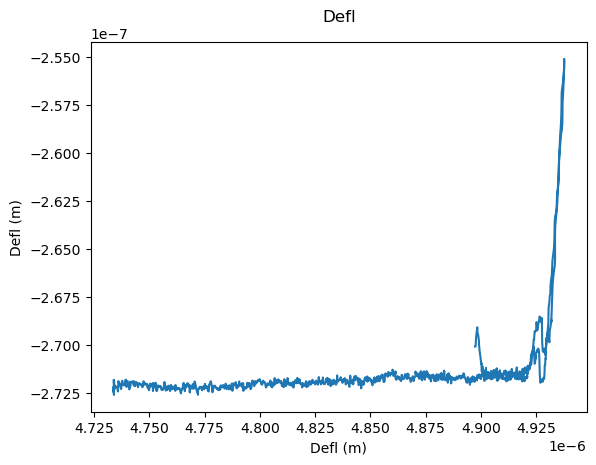

In [18]:
# Each channel is a sidpy Dataset, so we can plot it directly.
first_channel = datasets['Channel_001']
print(first_channel)
first_channel.plot();

## Read the TEM file

Same two lines, different format. AutoReader picks a different reader this time.

In [11]:
reader = SciFiReaders.AutoReader('example.emd')
datasets = reader.read()

print('chosen reader:', reader.reader_cls.__name__)
print('channels found:', list(datasets.keys()))

chosen reader: EMDReader
channels found: ['Channel_000']


sidpy.Dataset of type SPECTRUM with:
 dask.array<array, shape=(2048,), dtype=uint16, chunksize=(1,), chunktype=numpy.ndarray>
 data contains: intensity (counts)
 and Dimensions: 
energy_scale:  energy (eV) of size (2048,)
 with metadata: ['experiment', 'EDS']


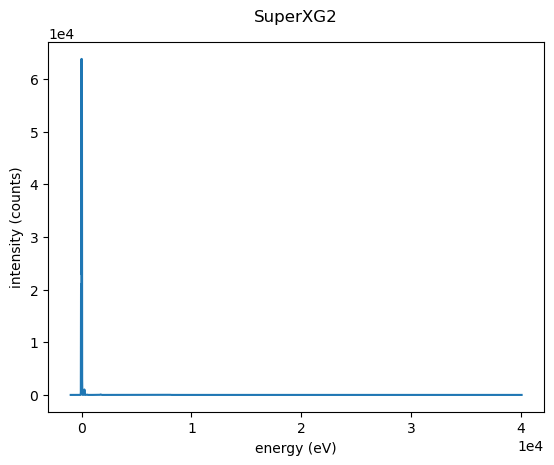

In [14]:
spectrum = datasets['Channel_000']
print(spectrum)
spectrum.plot();